# Loan Approval Prediction

## Machine Learning Project

Predicting loan approval status using applicant, financial, loan, and credit-related information.

## 1. Problem Definition

### Problem Statement

The goal of this project is to build a machine learning model
that predicts whether a loan application will be approved or rejected
based on applicant, financial, loan, and credit-related features.

### Machine Learning Type

- Learning Type: Supervised Learning
- Problem Type: Binary Classification
- Target Variable: `loan_status`

### Business Objective

The model is intended to support the loan assessment process by
providing a consistent prediction of loan approval status.

The model should be evaluated using multiple classification metrics
because false approvals and false rejections may have different
business consequences.

In [1]:
# =========================
# 2. Dataset Understanding
# =========================

import pandas as pd
import numpy as np

## 2. Dataset Understanding

### Load Dataset

In [2]:
df = pd.read_csv(
    r"D:\Summer 2026\ML-NTI\Smart-Banking-Analytics-Platform\datasets\loan\loan_data.csv")

In [3]:
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [4]:
df.shape

(45000, 14)

In [5]:
df.columns

Index(['person_age', 'person_gender', 'person_education', 'person_income',
       'person_emp_exp', 'person_home_ownership', 'loan_amnt', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'credit_score', 'previous_loan_defaults_on_file', 'loan_status'],
      dtype='str')

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

### Feature Description

| Feature | Description | Expected Type |
|---|---|---|
| `person_age` | Applicant age | Numerical |
| `person_income` | Applicant income | Numerical |
| `person_emp_exp` | Employment experience | Numerical |
| `loan_amnt` | Requested loan amount | Numerical |
| `loan_int_rate` | Loan interest rate | Numerical |
| `loan_percent_income` | Loan amount relative to income | Numerical |
| `cb_person_cred_hist_length` | Credit history length | Numerical |
| `credit_score` | Applicant credit score | Numerical |
| `person_gender` | Applicant gender | Categorical |
| `person_education` | Applicant education level | Categorical |
| `person_home_ownership` | Home ownership status | Categorical |
| `loan_intent` | Purpose of the loan | Categorical |
| `previous_loan_defaults_on_file` | Previous loan default status | Categorical |
| `loan_status` | Loan approval outcome | Target |

### 3. Dataset Structure and Value Inspection

Before performing exploratory data analysis, we inspect missing values,
duplicate records, categorical values, and target values to understand
the quality and structure of the dataset.

In [7]:
df.isnull().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [8]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [9]:
print("Unique target values:")
print(df["loan_status"].unique())

print("\nTarget value counts:")
print(df["loan_status"].value_counts())

Unique target values:
[1 0]

Target value counts:
loan_status
0    35000
1    10000
Name: count, dtype: int64


### Categorical Values

In [10]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include="object").columns

for col in categorical_cols:
    print(f"\n{col}")
    print(df[col].unique())


person_gender
<ArrowStringArray>
['female', 'male']
Length: 2, dtype: str

person_education
<ArrowStringArray>
['Master', 'High School', 'Bachelor', 'Associate', 'Doctorate']
Length: 5, dtype: str

person_home_ownership
<ArrowStringArray>
['RENT', 'OWN', 'MORTGAGE', 'OTHER']
Length: 4, dtype: str

loan_intent
<ArrowStringArray>
[         'PERSONAL',         'EDUCATION',           'MEDICAL',
           'VENTURE',   'HOMEIMPROVEMENT', 'DEBTCONSOLIDATION']
Length: 6, dtype: str

previous_loan_defaults_on_file
<ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str


C:\Users\Mustafa Hussein\AppData\Local\Temp\ipykernel_33612\3025381906.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


### Numerical Data Validation

Numerical features are inspected to identify unrealistic,
invalid, or suspicious values before performing exploratory data analysis.

In [11]:
numeric_cols = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"]

In [12]:
# Display descriptive statistics for numerical features
df[numeric_cols].describe()

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
count,45000.000000,4.500000e+04,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000,45000.000000
mean,27.764178,8.031905e+04,5.410333,9583.157556,11.006606,0.139725,5.867489,632.608756
std,6.045108,8.042250e+04,6.063532,6314.886691,2.978808,0.087212,3.879702,50.435865
min,20.000000,8.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,390.000000
25%,24.000000,4.720400e+04,1.000000,5000.000000,8.590000,0.070000,3.000000,601.000000
50%,26.000000,6.704800e+04,4.000000,8000.000000,11.010000,0.120000,4.000000,640.000000
75%,30.000000,9.578925e+04,8.000000,12237.250000,12.990000,0.190000,8.000000,670.000000
max,144.000000,7.200766e+06,125.000000,35000.000000,20.000000,0.660000,30.000000,850.000000


In [13]:
# Check for unrealistic applicant ages
print("Age < 18:", (df["person_age"] < 18).sum())
print("Age > 80:", (df["person_age"] > 80).sum())

Age < 18: 0
Age > 80: 9


In [14]:
# Check whether employment experience is greater than applicant age
print(
    "Employment experience > age:",
    (df["person_emp_exp"] > df["person_age"]).sum() )

Employment experience > age: 0


In [15]:
# Check for negative income values
print("Income < 0:", (df["person_income"] < 0).sum())

Income < 0: 0


In [16]:
print("Maximum income:", df["person_income"].max())

Maximum income: 7200766.0


In [17]:
# Check for negative loan amounts
print("Loan amount < 0:", (df["loan_amnt"] < 0).sum())

Loan amount < 0: 0


In [18]:
# Check whether loan-to-income ratio is outside the expected range
print(
    "Loan percent income < 0:",
    (df["loan_percent_income"] < 0).sum()
)

print(
    "Loan percent income > 1:",
    (df["loan_percent_income"] > 1).sum()
)

Loan percent income < 0: 0
Loan percent income > 1: 0


In [19]:
# Check for negative credit history length
print(
    "Credit history length < 0:",
    (df["cb_person_cred_hist_length"] < 0).sum()
)

Credit history length < 0: 0


In [20]:
print("Credit score <= 0:", (df["credit_score"] <= 0).sum())

Credit score <= 0: 0


In [21]:
# Check for invalid credit score values
print("Credit score <= 0:", (df["credit_score"] <= 0).sum())

# Display the minimum and maximum credit scores
print("Minimum credit score:", df["credit_score"].min())
print("Maximum credit score:", df["credit_score"].max())

Credit score <= 0: 0
Minimum credit score: 390
Maximum credit score: 850


In [22]:
# Display applicants with unusually high ages
df[df["person_age"] > 80][
    ["person_age", "person_income", "person_emp_exp", "credit_score", "loan_status"]
]

,person_age,person_income,person_emp_exp,credit_score,loan_status
81,144.0,300616.0,125,789,0
183,144.0,241424.0,121,807,0
575,123.0,97140.0,101,805,0
747,123.0,94723.0,100,714,0
32297,144.0,7200766.0,124,850,0
32416,94.0,29738.0,76,773,0
32506,84.0,114705.0,61,784,0
37930,116.0,5545545.0,93,708,0
38113,109.0,5556399.0,85,792,0


In [22]:
# Display applicants with extremely high income
df.nlargest(10, "person_income")[
    ["person_age", "person_income", "person_emp_exp", "loan_amnt", "credit_score"]
]

,person_age,person_income,person_emp_exp,loan_amnt,credit_score
32297,144.0,7200766.0,124,5000.0,850
38113,109.0,5556399.0,85,6195.0,792
37930,116.0,5545545.0,93,3823.0,708
30049,42.0,2448661.0,16,8450.0,635
32546,60.0,2280980.0,37,1500.0,682
32497,63.0,2139143.0,43,12025.0,724
37175,42.0,2012954.0,19,9121.0,664
41288,46.0,1741243.0,22,12011.0,655
31924,44.0,1728974.0,20,6400.0,573
35850,47.0,1661567.0,22,6545.0,622


## 4. Data Cleaning

Clearly unrealistic or extreme values are removed before continuing
with exploratory data analysis.

In [23]:
# Check the age distribution before cleaning
print("=== Age Distribution ===")
print(f'Min age: {df["person_age"].min()}')
print(f'Max age: {df["person_age"].max()}')
print(f'Ages over 110: {(df["person_age"] > 110).sum()}')

=== Age Distribution ===
Min age: 20.0
Max age: 144.0
Ages over 110: 6


In [24]:
# Remove applicants with age above 110
df_clean = df[df["person_age"] <= 110].copy()

print(f"Rows removed: {len(df) - len(df_clean)}")
print(f"Remaining rows: {len(df_clean)}")

Rows removed: 6
Remaining rows: 44994


In [25]:
# Check the income distribution after age cleaning
print("=== Income Distribution ===")
print(f'Min income: ${df_clean["person_income"].min():,.0f}')
print(f'Max income: ${df_clean["person_income"].max():,.0f}')
print(f'Mean income: ${df_clean["person_income"].mean():,.0f}')
print(f'Incomes over $1M: {(df_clean["person_income"] > 1_000_000).sum()}')

=== Income Distribution ===
Min income: $8,000
Max income: $5,556,399
Mean income: $80,030
Incomes over $1M: 22


"A small number of extreme age values were identified. These observations were reviewed and handled as outliers before modeling."

In [26]:
# Remove applicants with income above $1 million
rows_before = len(df_clean)

df_clean = df_clean[
    df_clean["person_income"] <= 1_000_000
].copy()

print(f"Rows removed: {rows_before - len(df_clean)}")
print(f"Remaining rows: {len(df_clean)}")

Rows removed: 22
Remaining rows: 44972


In [27]:
# Check target distribution after cleaning
print("=== Target Distribution After Cleaning ===")
print(df_clean["loan_status"].value_counts())

print("\nTarget percentages:")
print(
    df_clean["loan_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

=== Target Distribution After Cleaning ===
loan_status
0    34972
1    10000
Name: count, dtype: int64

Target percentages:
loan_status
0    77.76
1    22.24
Name: proportion, dtype: float64


## 5. Exploratory Data Analysis (EDA)

### Target Variable Analysis

The target variable is analyzed first to understand its class
distribution and identify potential class imbalance.

In [28]:
# Display the number of observations in each target class
df_clean["loan_status"].value_counts()

loan_status
0    34972
1    10000
Name: count, dtype: int64

In [29]:
# Display the percentage of observations in each target class
df_clean["loan_status"].value_counts(normalize=True).mul(100).round(2)

loan_status
0    77.76
1    22.24
Name: proportion, dtype: float64

In [30]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

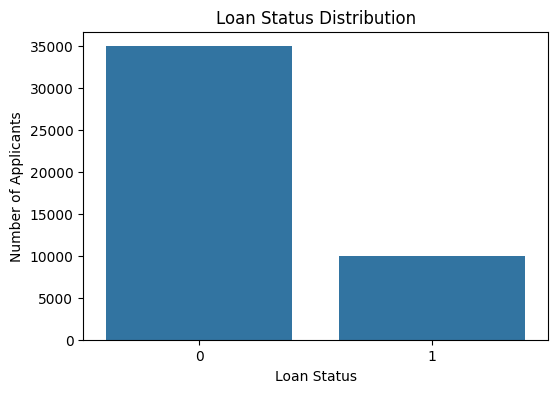

In [31]:
# Visualize the distribution of the target variable
plt.figure(figsize=(6, 4))

sns.countplot(data=df_clean, x="loan_status")

plt.title("Loan Status Distribution")
plt.xlabel("Loan Status")
plt.ylabel("Number of Applicants")

plt.show()

### Target Variable Analysis

The target variable is imbalanced, with rejected loan applications representing the majority of the dataset. Therefore, accuracy alone is not sufficient for evaluating model performance, and metrics such as precision, recall, and F1-score are also considered.

### Numerical Features Distribution

The distributions of numerical features are visualized to understand
their spread, skewness, and potential extreme values.

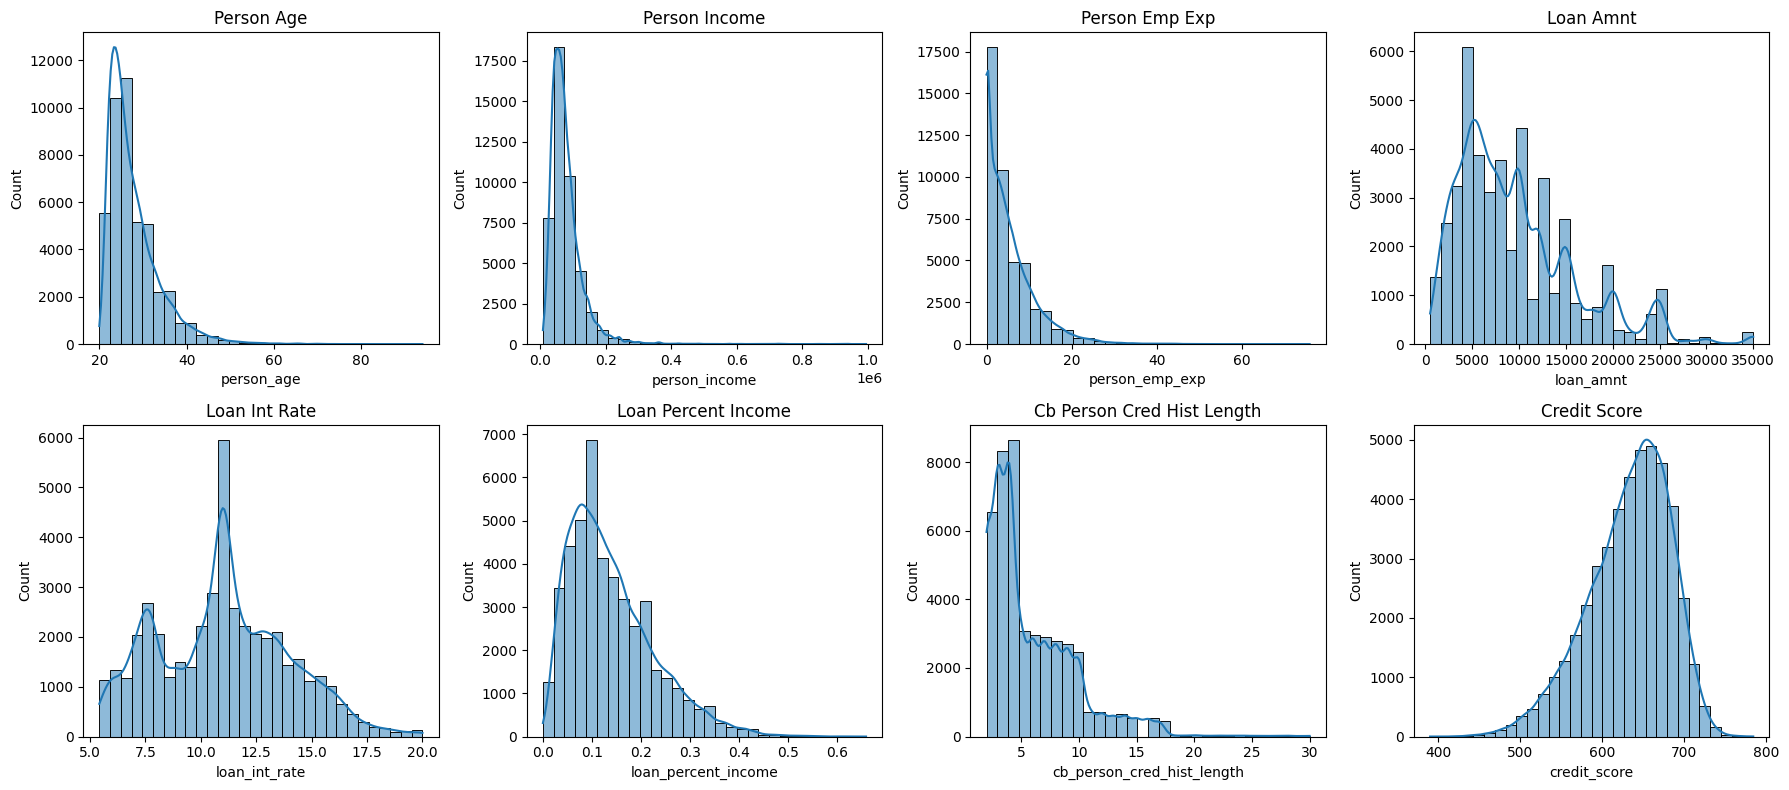

In [32]:
# Plot distributions of numerical features

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df_clean, x=col, bins=30, kde=True, ax=ax)
    ax.set_title(col.replace("_", " ").title())

plt.tight_layout()
plt.show()

### Numerical Features Distribution - Summary

- `person_age`, `person_income`, and `person_emp_exp` are right-skewed.
- `loan_amnt` shows several noticeable peaks.
- `loan_int_rate` has multiple peaks across its range.
- `loan_percent_income` is right-skewed.
- `cb_person_cred_hist_length` is right-skewed.
- `credit_score` has a more balanced distribution.

### Numerical Features vs Target

The distributions of numerical features are compared across target
classes to identify potential differences between the two groups.

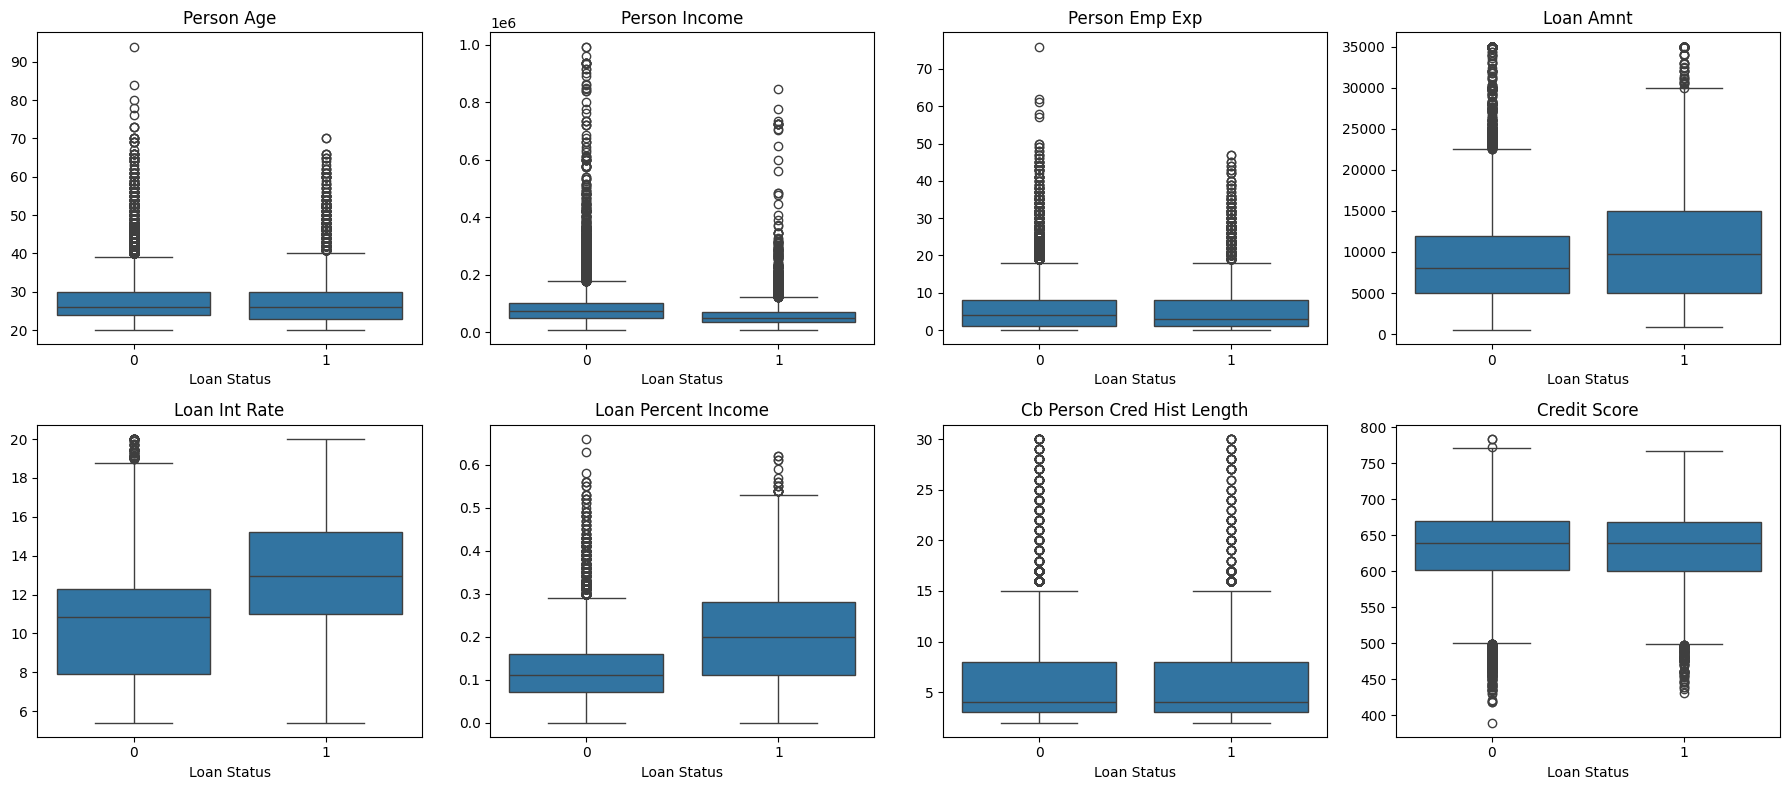

In [33]:
# Compare numerical features across target classes

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, col in zip(axes, numeric_cols):
    sns.boxplot(data=df_clean, x="loan_status", y=col, ax=ax)
    ax.set_title(col.replace("_", " ").title())
    ax.set_xlabel("Loan Status")
    ax.set_ylabel("")

plt.tight_layout()
plt.show()

- `loan_int_rate` and `loan_percent_income` show clear differences between the two classes.
- `loan_amnt` also shows some difference between the classes.
- `person_age`, `credit_score`, and credit history length show similar distributions.
- `person_income` and `person_emp_exp` contain several extreme values.

### Categorical Features vs Target

We analyze the distribution of categorical features across the target classes
to identify potential relationships with loan status.

In [34]:
# Compare categorical features across target classes

for col in categorical_cols:
    print(f"\n{col}")
    print(pd.crosstab(df[col], df_clean["loan_status"], normalize="index").mul(100).round(2))


person_gender
loan_status        0      1
person_gender              
female         77.74  22.26
male           77.78  22.22

person_education
loan_status           0      1
person_education              
Associate         77.96  22.04
Bachelor          77.47  22.53
Doctorate         77.10  22.90
High School       77.66  22.34
Master            78.23  21.77

person_home_ownership
loan_status                0      1
person_home_ownership              
MORTGAGE               88.39  11.61
OTHER                  66.67  33.33
OWN                    92.47   7.53
RENT                   67.59  32.41

loan_intent
loan_status            0      1
loan_intent                    
DEBTCONSOLIDATION  69.71  30.29
EDUCATION          83.04  16.96
HOMEIMPROVEMENT    73.70  26.30
MEDICAL            72.17  27.83
PERSONAL           79.84  20.16
VENTURE            85.56  14.44

previous_loan_defaults_on_file
loan_status                          0      1
previous_loan_defaults_on_file               
No    

In [35]:
# Compare loan intent across target classes
print(
    pd.crosstab(
        df_clean["loan_intent"],
        df_clean["loan_status"],
        normalize="index"
    ).mul(100).round(2) )

loan_status            0      1
loan_intent                    
DEBTCONSOLIDATION  69.71  30.29
EDUCATION          83.04  16.96
HOMEIMPROVEMENT    73.70  26.30
MEDICAL            72.17  27.83
PERSONAL           79.84  20.16
VENTURE            85.56  14.44


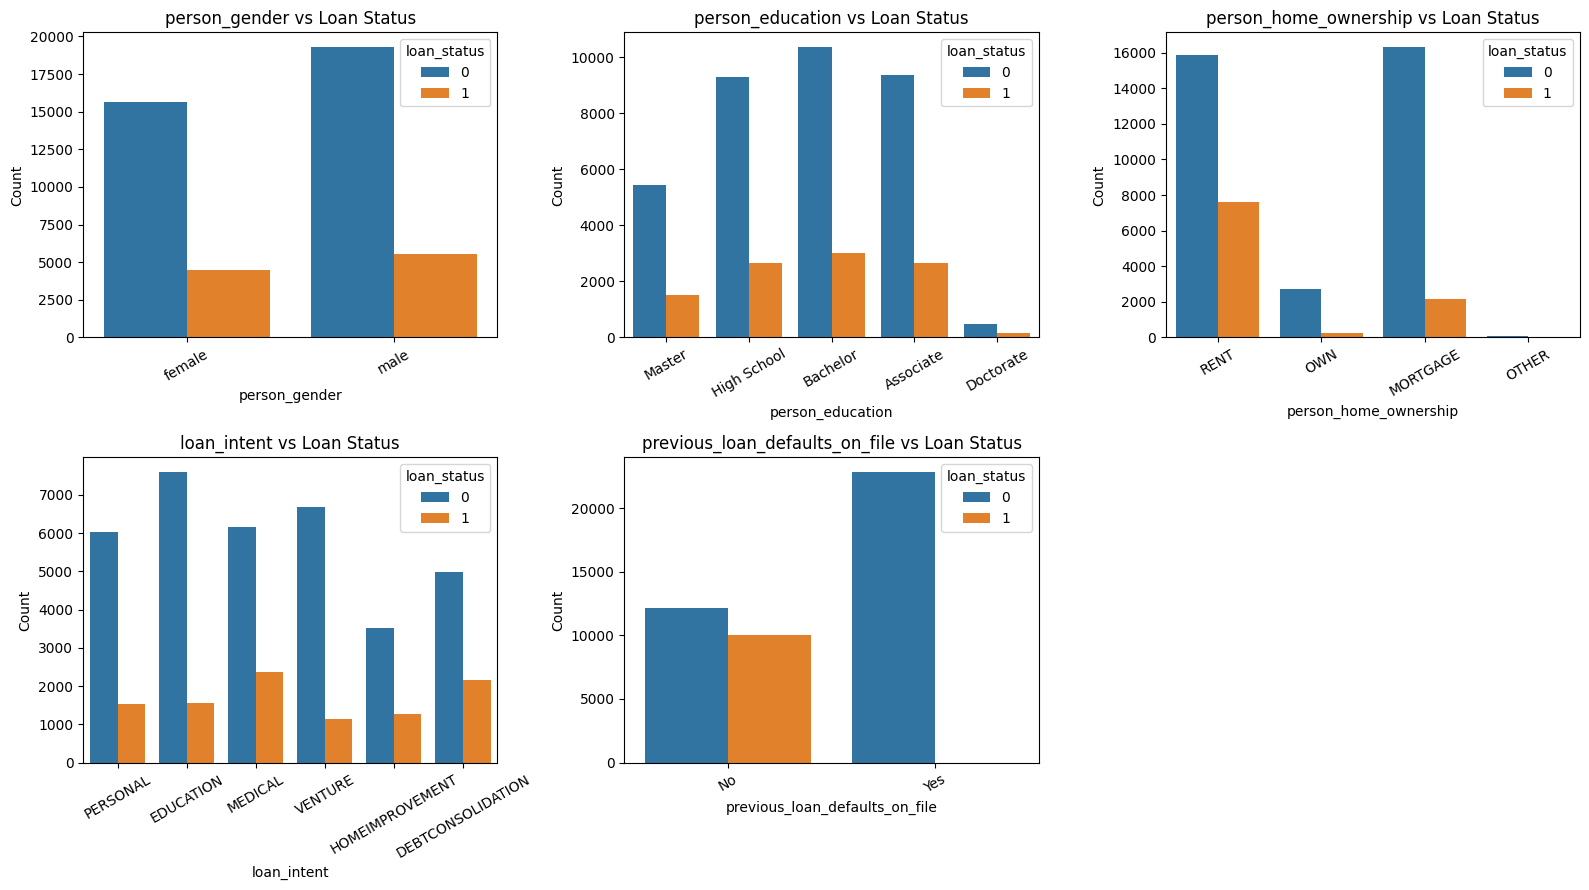

In [37]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(
        data=df_clean,
        x=col,
        hue="loan_status",
        ax=axes[i]
    )
    
    axes[i].set_title(f"{col} vs Loan Status")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")
    axes[i].tick_params(axis="x", rotation=30)

# Remove the empty subplot
fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

- `person_gender` and `person_education` show little difference between the target classes.
- `person_home_ownership` shows noticeable differences across categories.
- `loan_intent` shows moderate differences between categories.
- `previous_loan_defaults_on_file` shows a very strong relationship with the target and requires further investigation.

### Correlation Analysis

Correlation analysis is used to examine the relationships between
numerical features and identify potentially highly correlated features.

In [36]:
# Calculate the correlation matrix for numerical features
correlation_matrix = df_clean[numeric_cols].corr()

correlation_matrix

,person_age,person_income,person_emp_exp,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score
person_age,1.000000,0.132408,0.952104,0.051578,0.012773,-0.040153,0.878227,0.174823
person_income,0.132408,1.000000,0.121129,0.359128,0.000343,-0.314456,0.116357,0.028544
person_emp_exp,0.952104,0.121129,1.000000,0.045207,0.016032,-0.036616,0.839545,0.182771
loan_amnt,0.051578,0.359128,0.045207,1.000000,0.146027,0.593794,0.042709,0.009090
loan_int_rate,0.012773,0.000343,0.016032,0.146027,1.000000,0.125287,0.017857,0.011190
loan_percent_income,-0.040153,-0.314456,-0.036616,0.593794,0.125287,1.000000,-0.029715,-0.011069
cb_person_cred_hist_length,0.878227,0.116357,0.839545,0.042709,0.017857,-0.029715,1.000000,0.154801
credit_score,0.174823,0.028544,0.182771,0.009090,0.011190,-0.011069,0.154801,1.000000


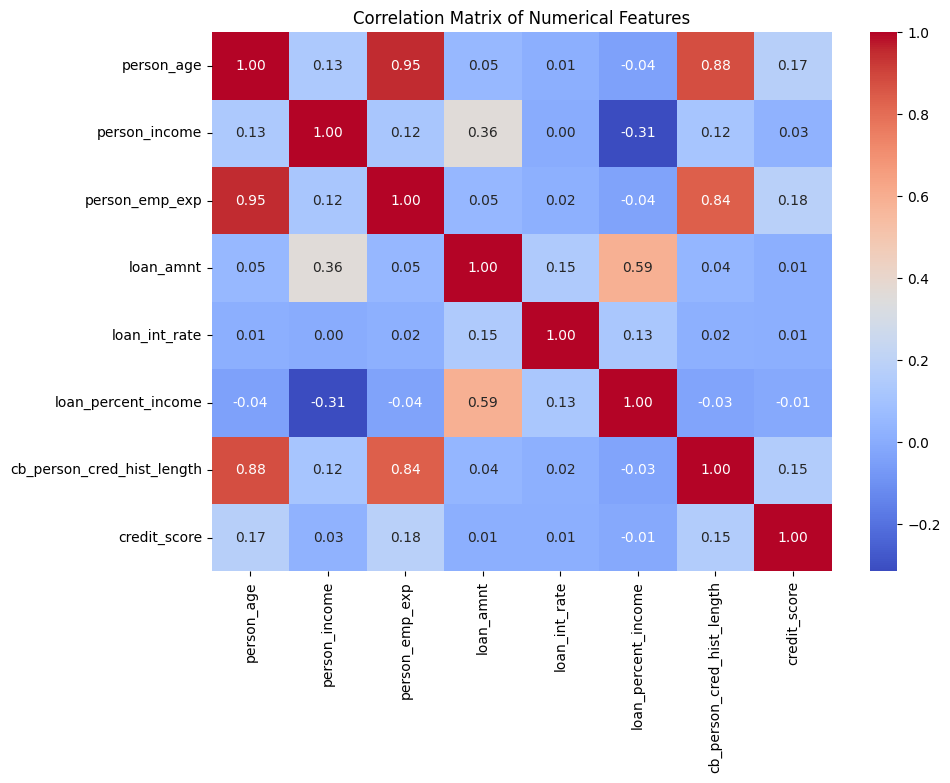

In [37]:
# Visualize correlations between numerical features

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerical Features")
plt.show()

- Strong correlations were found between `person_age`, `person_emp_exp`, and `cb_person_cred_hist_length`.
- The strongest correlation is between `person_age` and `person_emp_exp`.
- `loan_amnt` and `loan_percent_income` show a moderate positive correlation.
- Most other numerical features have relatively weak correlations.
- The highly correlated features may indicate multicollinearity and will be considered during the modeling stage.

## 6. Feature and Target Preparation

The target variable is separated from the input features before
splitting the data into training and testing sets.

In [38]:
# Separate input features from the target variable

X = df_clean.drop("loan_status", axis=1)
y = df_clean["loan_status"]

In [39]:
# Check the shapes of features and target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (44972, 13)
y shape: (44972,)


## 7. Train / Test Split

The dataset is split into training and testing sets.
The training set is used to train the models, while the test set is kept
unseen for final model evaluation.

In [40]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y )

In [41]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (35977, 13)
X_test : (8995, 13)
y_train: (35977,)
y_test : (8995,)


In [44]:
# Check target distribution in training and testing sets

print("Training target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))

Training target distribution:
loan_status
0    77.76
1    22.24
Name: proportion, dtype: float64

Testing target distribution:
loan_status
0    77.77
1    22.23
Name: proportion, dtype: float64


The same proportions beacause stratify=y

## 8. Data Preprocessing

Numerical and categorical features require different preprocessing steps.
Numerical features will be scaled, while categorical features will be
encoded using one-hot encoding.

The preprocessing steps will be fitted only on the training data to
avoid data leakage.

In [42]:
# Define numerical and categorical features

numeric_features = [
    "person_age",
    "person_income",
    "person_emp_exp",
    "loan_amnt",
    "loan_int_rate",
    "loan_percent_income",
    "cb_person_cred_hist_length",
    "credit_score"
]

categorical_features = [
    "person_gender",
    "person_education",
    "person_home_ownership",
    "loan_intent",
    "previous_loan_defaults_on_file"
]

In [43]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [44]:
# Create preprocessing pipelines for numerical and categorical features

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

## 9. Baseline Model

Logistic Regression is used as the baseline classification model.
It provides a simple and interpretable benchmark against which more
complex models can be compared.

In [45]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

In [46]:
# Create a pipeline combining preprocessing and Logistic Regression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000,class_weight='balanced'))
    ]
)

In [47]:
# Train the Logistic Regression baseline model
logistic_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [48]:
# Generate predictions on the test set
y_pred = logistic_pipeline.predict(X_test)

In [49]:
# Generate predicted probabilities for the positive class
y_proba = logistic_pipeline.predict_proba(X_test)[:, 1]

### Baseline Evaluation

The baseline model is evaluated using multiple classification metrics
rather than accuracy alone, given the class imbalance in the target variable.

In [50]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score )


In [51]:
# Calculate baseline evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Accuracy : 0.8527
Precision: 0.6127
Recall   : 0.9175
F1-Score : 0.7347
ROC-AUC  : 0.9536


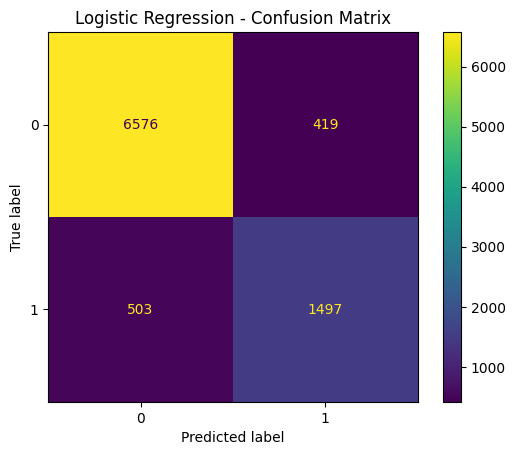

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

# Display the confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

plt.title("Logistic Regression - Confusion Matrix")
plt.show()

In [52]:
from sklearn.metrics import classification_report

# Display detailed classification metrics
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.83      0.90      6995
           1       0.61      0.92      0.73      2000

    accuracy                           0.85      8995
   macro avg       0.79      0.88      0.82      8995
weighted avg       0.89      0.85      0.86      8995



### Baseline Model - Results

The Logistic Regression baseline achieved an accuracy of 89.75% and a ROC-AUC
of 95.37%.

For Class 1, the model achieved a precision of 78.13%, a recall of 74.85%,
and an F1-score of 76.46%.

The model performs better on Class 0, with a precision of 93% and a recall
of 94%. This difference is partly related to the class imbalance in the
target variable.

The baseline provides a strong reference point for comparing more complex
models.

## 10. Model Comparison

Several classification models are trained and evaluated using the same
training and testing sets. The goal is to compare their performance
before performing cross-validation and hyperparameter tuning.

In [53]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

In [58]:
from xgboost import XGBClassifier

# Calculate class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

print("scale_pos_weight =", scale_pos_weight)

scale_pos_weight = 3.497125


In [59]:
# Create pipelines for the models to be compared

models = {
    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", RandomForestClassifier(
                n_estimators=200,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1
            ))
        ]
    ),

    "Gradient Boosting": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", GradientBoostingClassifier(
               
                random_state=42
                
            ))
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", XGBClassifier(
                n_estimators=200,
                max_depth=6,
                 scale_pos_weight=scale_pos_weight,
                learning_rate=0.1,
                random_state=42,
                eval_metric="logloss"
            ))
        ]
    )
}

In [60]:
# Train each model and generate predictions

model_predictions = {}

for name, model in models.items():

    print(f"Training {name}...")

    model.fit(X_train, y_train)

    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    model_predictions[name] = (predictions, probabilities)

Training Random Forest...
Training Gradient Boosting...
Training XGBoost...


In [61]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score )

In [62]:
# Evaluate all comparison models

results = []

for name, (predictions, probabilities) in model_predictions.items():

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1-Score": f1_score(y_test, predictions),
        "ROC-AUC": roc_auc_score(y_test, probabilities)
    })

In [63]:
# Add the Logistic Regression baseline to the comparison

results.append({
    "Model": "Logistic Regression",
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-Score": f1_score(y_test, y_pred),
    "ROC-AUC": roc_auc_score(y_test, y_proba)
})

In [ ]:
# Create the final comparison table

results_df = pd.DataFrame(results)

results_df = results_df[
    [
        "Model",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score",
        "ROC-AUC"
    ]
]

results_df.round(4)

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Random Forest,0.9275,0.8910,0.7680,0.8249,0.9742
1,Gradient Boosting,0.9240,0.8834,0.7580,0.8159,0.9718
2,XGBoost,0.9354,0.8966,0.8020,0.8467,0.9786
3,Logistic Regression,0.8975,0.7813,0.7485,0.7646,0.9537


- XGBoost achieved the best overall performance across the evaluated metrics.
- XGBoost achieved the highest F1-score (84.67%), Recall (80.20%), and ROC-AUC (97.86%).
- Random Forest was the second strongest model, followed by Gradient Boosting.
- Logistic Regression provided a useful baseline but performed lower than the tree-based models.
- Based on these initial results, XGBoost and Random Forest will be considered strong candidates for further validation and tuning.
- The initial test-set results will not be used alone to select the final model. Further evaluation will be performed using cross-validation on the training data.

## 11. Stratified Cross-Validation

Stratified cross-validation is used to evaluate model performance across
multiple folds while preserving the class distribution in each fold.

Cross-validation is performed only on the training data. The test set
remains unseen and will be used only for the final evaluation.

In [64]:
from sklearn.model_selection import StratifiedKFold, cross_validate

In [65]:
# Create stratified 5-fold cross-validation
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42 )

In [66]:
# Define evaluation metrics for cross-validation
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc" }

In [67]:
# Evaluate selected models using cross-validation

cv_results = []

for name, model in models.items():

    # Skip Gradient Boosting from cross-validation
    if name == "Gradient Boosting":
        continue

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "Train F1 Mean": scores["train_f1"].mean(),
        "Validation F1 Mean": scores["test_f1"].mean(),
        "Train ROC-AUC Mean": scores["train_roc_auc"].mean(),
        "Validation ROC-AUC Mean": scores["test_roc_auc"].mean(),
        "Validation F1 Std": scores["test_f1"].std(),
        "Validation ROC-AUC Std": scores["test_roc_auc"].std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)

,Model,Train F1 Mean,Validation F1 Mean,Train ROC-AUC Mean,Validation ROC-AUC Mean,Validation F1 Std,Validation ROC-AUC Std
0,Random Forest,1.0000,0.8203,1.0000,0.9734,0.0090,0.0013
1,XGBoost,0.8922,0.8241,0.9933,0.9783,0.0029,0.0013


The cross-validation results show that Random Forest has a significant
gap between training and validation performance, indicating overfitting.

XGBoost shows a smaller train-validation gap and achieves higher mean
validation F1-score and ROC-AUC than Random Forest.

The validation scores also have low standard deviations, indicating
consistent performance across the folds.

Based on these results, XGBoost is currently the strongest candidate
for hyperparameter tuning, while Random Forest will be considered as
a secondary candidate.

## 12. Hyperparameter Tuning

Hyperparameter tuning is used to find a better configuration for the
XGBoost model.

The tuning process is performed using cross-validation on the training
data only. The test set remains unseen until the final evaluation.

The main objective is to improve validation performance while avoiding
excessive overfitting.

In [68]:
from sklearn.model_selection import RandomizedSearchCV

In [69]:
# Define the hyperparameter search space for XGBoost

param_grid = {
    "model__n_estimators": [100, 200, 300, 500],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__learning_rate": [0.01, 0.05, 0.1, 0.2],
    "model__min_child_weight": [1, 3, 5, 7],
    "model__subsample": [0.7, 0.8, 0.9, 1.0],
    "model__colsample_bytree": [0.7, 0.8, 0.9, 1.0]
}

In [70]:
# Create RandomizedSearchCV for XGBoost

xgb_random_search = RandomizedSearchCV(
    estimator=models["XGBoost"],
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1",
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1

)

In [71]:
# Run hyperparameter tuning

xgb_random_search.fit(X_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.05, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",30
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation st

In [72]:
# Display the best hyperparameters

print("Best parameters:")
print(xgb_random_search.best_params_)

Best parameters:
{'model__subsample': 0.7, 'model__n_estimators': 500, 'model__min_child_weight': 3, 'model__max_depth': 6, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.7}


In [73]:
# Display the best cross-validation F1-score

print("Best CV F1-score:")
print(round(xgb_random_search.best_score_, 4))

Best CV F1-score:
0.8373


In [74]:
# Store the best XGBoost model found during tuning

best_xgb_model = xgb_random_search.best_estimator_

In [75]:
# Evaluate the tuned XGBoost using cross-validation

tuned_xgb_scores = cross_validate(
    best_xgb_model,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1
)

In [76]:
# Compare training and validation performance after tuning

print(
    "Train F1 Mean:",
    round(tuned_xgb_scores["train_f1"].mean(), 4)
)

print(
    "Validation F1 Mean:",
    round(tuned_xgb_scores["test_f1"].mean(), 4)
)

print(
    "Train ROC-AUC Mean:",
    round(tuned_xgb_scores["train_roc_auc"].mean(), 4)
)

print(
    "Validation ROC-AUC Mean:",
    round(tuned_xgb_scores["test_roc_auc"].mean(), 4)
)

Train F1 Mean: 0.9634
Validation F1 Mean: 0.8373
Train ROC-AUC Mean: 0.9994
Validation ROC-AUC Mean: 0.9779


### Overfitting Check After Tuning

The tuned XGBoost model shows a noticeable gap between training and
validation F1-score, indicating some degree of overfitting. However,
the validation performance remains strong, with a high ROC-AUC score.

The tuned model will now be evaluated on the unseen test set for the
final performance assessment.

## 13. Final Test Evaluation

The tuned XGBoost model is evaluated on the unseen test set.

The test set was not used during model selection or hyperparameter tuning,
so these results provide the final estimate of the model's generalization
performance.

In [77]:
# Generate final predictions on the unseen test set

y_test_pred = best_xgb_model.predict(X_test)
y_test_proba = best_xgb_model.predict_proba(X_test)[:, 1]

In [78]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

# Calculate final test-set performance

final_accuracy = accuracy_score(y_test, y_test_pred)
final_precision = precision_score(y_test, y_test_pred)
final_recall = recall_score(y_test, y_test_pred)
final_f1 = f1_score(y_test, y_test_pred)
final_roc_auc = roc_auc_score(y_test, y_test_proba)

print("Final Test Performance")
print("----------------------")
print("Accuracy :", round(final_accuracy, 4))
print("Precision:", round(final_precision, 4))
print("Recall   :", round(final_recall, 4))
print("F1-Score :", round(final_f1, 4))
print("ROC-AUC  :", round(final_roc_auc, 4))

Final Test Performance
----------------------
Accuracy : 0.9262
Precision: 0.7993
Recall   : 0.892
F1-Score : 0.8431
ROC-AUC  : 0.9784


In [79]:
from sklearn.metrics import classification_report

# Display detailed classification metrics

print(classification_report(y_test, y_test_pred))

              precision    recall  f1-score   support

           0       0.97      0.94      0.95      6995
           1       0.80      0.89      0.84      2000

    accuracy                           0.93      8995
   macro avg       0.88      0.91      0.90      8995
weighted avg       0.93      0.93      0.93      8995



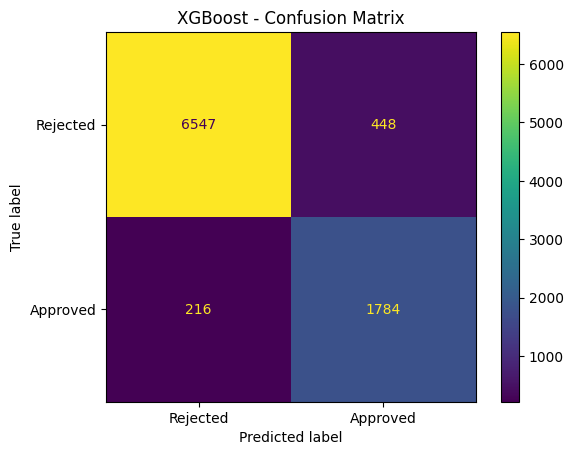

In [80]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Display the confusion matrix

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Rejected", "Approved"]
)

disp.plot()
plt.title("XGBoost - Confusion Matrix")
plt.show()

## 14. Threshold Analysis

The default classification threshold of 0.50 is not necessarily optimal for loan approval decisions. Therefore, several thresholds are evaluated to study the trade-off between precision and recall.

In [81]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6]

threshold_results = []

for threshold in thresholds:

    y_pred_threshold = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, y_pred_threshold),
        "Recall": recall_score(y_test, y_pred_threshold),
        "F1-Score": f1_score(y_test, y_pred_threshold)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df.round(4)

,Threshold,Precision,Recall,F1-Score
0,0.3,0.7033,0.9365,0.8033
1,0.4,0.7556,0.9150,0.8277
2,0.5,0.7993,0.8920,0.8431
3,0.6,0.8432,0.8575,0.8503


In [82]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1-Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Selected Threshold:", best_threshold)

Selected Threshold: 0.6


FINAL MODEL - NEW THRESHOLD
Threshold : 0.6
Accuracy  : 0.9329
Precision : 0.8432
Recall    : 0.8575
F1-Score  : 0.8503
ROC-AUC   : 0.9784

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.95      0.96      6995
           1       0.84      0.86      0.85      2000

    accuracy                           0.93      8995
   macro avg       0.90      0.91      0.90      8995
weighted avg       0.93      0.93      0.93      8995



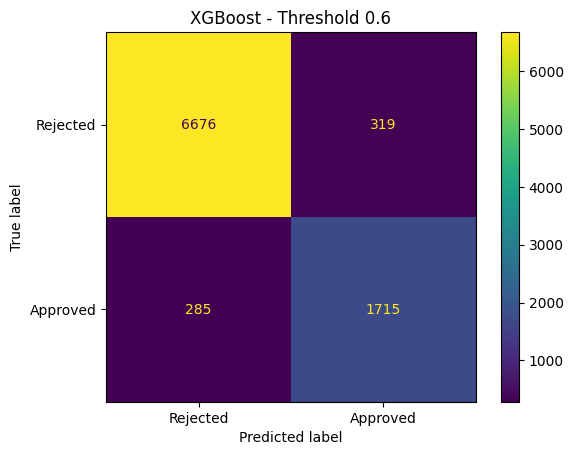


Model with new threshold saved to:
D:\banking-ml-platform\models\loan\loan_final_model_threshold_060.pkl


In [83]:
# ============================================
# FINAL MODEL WITH NEW THRESHOLD
# ============================================

import joblib
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
import matplotlib.pyplot as plt


# Keep the original final model unchanged
threshold_model = best_xgb_model


# New selected threshold
selected_threshold = 0.60


# Get probabilities from the original final model
threshold_proba = threshold_model.predict_proba(X_test)[:, 1]


# Apply the new threshold
threshold_pred = (
    threshold_proba >= selected_threshold
).astype(int)


# ============================================
# Evaluation After Applying New Threshold
# ============================================

threshold_accuracy = accuracy_score(
    y_test,
    threshold_pred
)

threshold_precision = precision_score(
    y_test,
    threshold_pred
)

threshold_recall = recall_score(
    y_test,
    threshold_pred
)

threshold_f1 = f1_score(
    y_test,
    threshold_pred
)

threshold_roc_auc = roc_auc_score(
    y_test,
    threshold_proba
)


print("========================================")
print("FINAL MODEL - NEW THRESHOLD")
print("========================================")

print("Threshold :", selected_threshold)
print("Accuracy  :", round(threshold_accuracy, 4))
print("Precision :", round(threshold_precision, 4))
print("Recall    :", round(threshold_recall, 4))
print("F1-Score  :", round(threshold_f1, 4))
print("ROC-AUC   :", round(threshold_roc_auc, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        threshold_pred
    )
)


# ============================================
# Confusion Matrix
# ============================================

threshold_cm = confusion_matrix(
    y_test,
    threshold_pred
)

threshold_disp = ConfusionMatrixDisplay(
    confusion_matrix=threshold_cm,
    display_labels=["Rejected", "Approved"]
)

threshold_disp.plot()

plt.title(
    f"XGBoost - Threshold {selected_threshold}"
)

plt.show()


# ============================================
# Save Model + New Threshold
# ============================================

threshold_model_package = {
    "model": threshold_model,
    "threshold": selected_threshold
}

threshold_model_path = (
    r"D:\banking-ml-platform\models\loan\loan_final_model_threshold_060.pkl"
)

joblib.dump(
    threshold_model_package,
    threshold_model_path
)

print("\nModel with new threshold saved to:")
print(threshold_model_path)

## 14. Model Explainability

Feature importance is used to understand which features contribute most to the final XGBoost model's predictions.

This provides a global view of the variables that are most influential in the model's decisions.

In [84]:
# ============================================
# 14. Model Explainability
# ============================================

# Get feature names after preprocessing
threshold_feature_names = (
    threshold_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)


# Get feature importance from the new final XGBoost model
threshold_feature_importance = (
    threshold_model
    .named_steps["model"]
    .feature_importances_
)


# Create a DataFrame containing feature importance
threshold_importance_df = pd.DataFrame({
    "Feature": threshold_feature_names,
    "Importance": threshold_feature_importance
})


# Sort features by importance
threshold_importance_df = threshold_importance_df.sort_values(
    by="Importance",
    ascending=False
)


# Display top 10 features
threshold_importance_df.head(10)

,Feature,Importance
26,cat__previous_loan_defaults_on_file_Yes,0.639167
25,cat__previous_loan_defaults_on_file_No,0.307252
18,cat__person_home_ownership_RENT,0.008204
17,cat__person_home_ownership_OWN,0.007171
24,cat__loan_intent_VENTURE,0.004203
5,num__loan_percent_income,0.003292
21,cat__loan_intent_HOMEIMPROVEMENT,0.003232
4,num__loan_int_rate,0.002688
1,num__person_income,0.002576
15,cat__person_home_ownership_MORTGAGE,0.002377


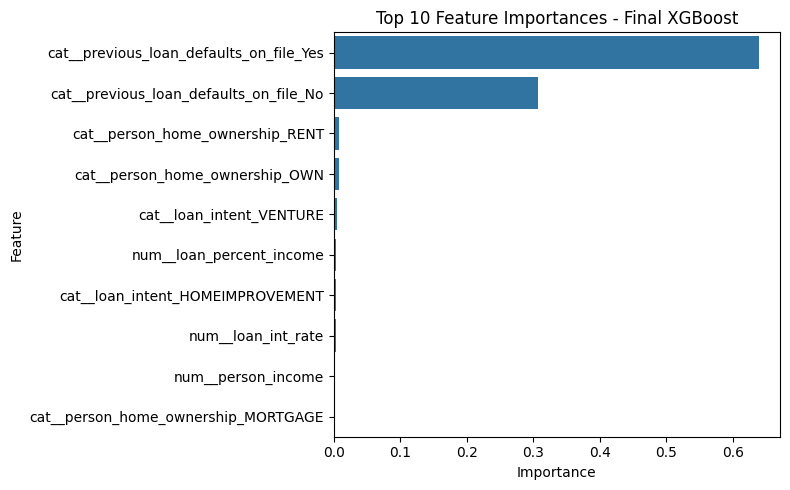

In [85]:
# ============================================
# Top 10 Feature Importances
# ============================================

plt.figure(figsize=(8, 5))

sns.barplot(
    data=threshold_importance_df.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Top 10 Feature Importances - Final XGBoost")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

## 16. Business Interpretation

The final XGBoost model provides a data-driven approach for supporting loan approval decisions.

The model's predictions can help identify applicants who are more likely to be approved based on their financial and loan-related characteristics.

The feature importance analysis shows that previous loan default history is the most influential factor, followed by factors such as home ownership, loan-to-income ratio, loan interest rate, loan intent, and personal income.

The selected classification threshold was 0.6, as it achieved the highest F1-score among the tested thresholds.

The model should be considered a decision-support tool rather than a replacement for human or business judgment.

=====================================================================================================================